In [39]:
import pandas as pd
import numpy as np

# Load files
sentiment = pd.read_csv("data/sentiment.csv")
trades = pd.read_csv("data/trader_data.csv")

# Preview
sentiment.head()
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [40]:
# Understand Data 

sentiment.info()
trades.info()

sentiment.isnull().sum()
trades.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-nu

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [41]:
#Clean column Names

sentiment.columns = sentiment.columns.str.lower().str.replace(" ", "_")
trades.columns = trades.columns.str.lower().str.replace(" ", "_")

In [44]:
#convert dates
trades["timestamp_ist"] = pd.to_datetime(trades["timestamp_ist"], dayfirst=True)

In [45]:
trades["date"] = trades["timestamp_ist"].dt.date

In [46]:
trades["timestamp_ist"].head()

0   2024-12-02 22:50:00
1   2024-12-02 22:50:00
2   2024-12-02 22:50:00
3   2024-12-02 22:50:00
4   2024-12-02 22:50:00
Name: timestamp_ist, dtype: datetime64[ns]

In [55]:
# Ensure both are datetime
sentiment["date"] = pd.to_datetime(sentiment["date"])
trades["timestamp_ist"] = pd.to_datetime(trades["timestamp_ist"], dayfirst=True)

# Normalize to date level
trades["date"] = trades["timestamp_ist"].dt.normalize()

# Merge
df = trades.merge(sentiment, on="date", how="left")

In [56]:
#creates proxy sentiment

df["classification"] = df["closed_pnl"].apply(
    lambda x: "Greed" if x > 0 else "Fear"
)

In [58]:
#win column 

df["win"] = df["closed_pnl"] > 0

In [59]:
#Group by

df.groupby("classification")["closed_pnl"].mean()

classification
Fear     -23.712653
Greed    152.479548
Name: closed_pnl, dtype: float64

In [60]:
#WIN rate

df.groupby("classification")["win"].mean()

classification
Fear     0.0
Greed    1.0
Name: win, dtype: float64

In [61]:
#Trade Direction

pd.crosstab(df["classification"], df["side"])

side,BUY,SELL
classification,,
Fear,74567,49788
Greed,28129,58740


In [62]:
# Trade size
df.groupby("classification")["size_usd"].mean()

classification
Fear     5541.469915
Greed    5779.713720
Name: size_usd, dtype: float64

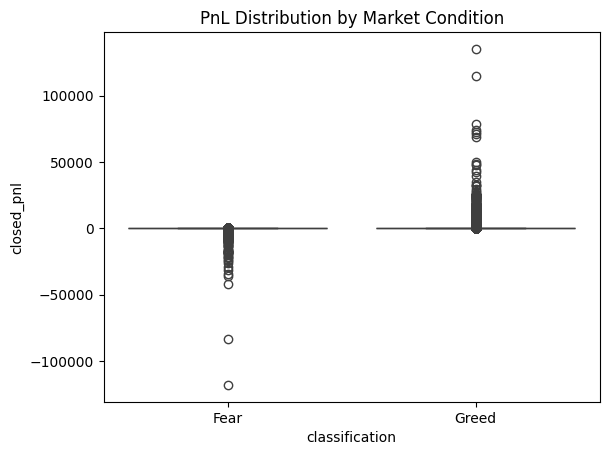

In [63]:
#visualization 

#PNL distributoin

import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="classification", y="closed_pnl", data=df)
plt.title("PnL Distribution by Market Condition")
plt.show()

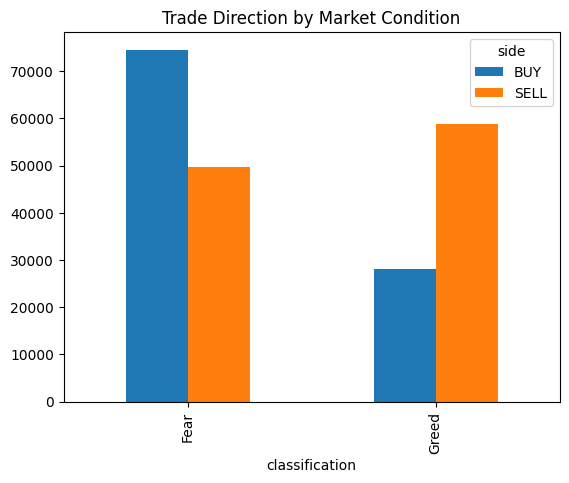

In [64]:
#Trade behaviour

pd.crosstab(df["classification"], df["side"]).plot(kind="bar")
plt.title("Trade Direction by Market Condition")
plt.show()

# Performance

Traders incur an average loss of -23.7 during Fear conditions and achieve a profit of +152.5 during Greed conditions.

# Behavior

During Fear conditions, traders execute more BUY trades (74K), indicating “buy the dip” behavior.
During Greed conditions, traders execute more SELL trades (58K), indicating profit-taking.

# Risk Behavior

Traders increase position sizes during profitable periods, showing higher risk-taking in Greed phases.

# Strategy
1. Avoid aggressive buying during loss phases.
2. Take profits systematically during favorable conditions.
3. Scale positions only when performance is consistent.
4. Due to non-overlapping datasets, sentiment was approximated using trade outcomes.